In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons, make_s_curve, make_swiss_roll

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere
from metrics import evaluate_conformality

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

Changed to Silu and increased NN size.

In [3]:
data, labels = make_swiss_roll(n_samples=3000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
data = data / torch.max(torch.abs(data), axis=0)[0] # Normalize data
val_data, val_labels = make_swiss_roll(n_samples=1000, noise=0.05, random_state=random_state+1)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)
val_data = val_data / torch.max(torch.abs(val_data), axis=0)[0] # Normalize validation data

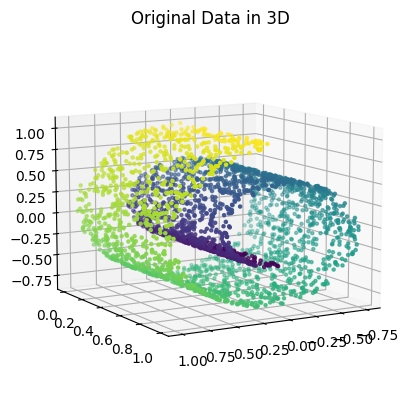

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(10, 60, 0)
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 128

train_dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)


dir_path = "models/conformal_autoencoder_trace_comp_realswissroll"

In [6]:
lambda_isos = np.logspace(-3, 2, 9)
lambda_isos = np.concat([np.zeros(1), lambda_isos])

In [7]:
from metrics import conformality_trace_loss

In [8]:
import os

def modelpath(dir_path, lambda_iso, index):
    os.makedirs(dir_path, exist_ok=True)
    return f"{dir_path}/lambda_{lambda_iso:.3f}_model_{index+1}.pth"

In [9]:
num_epochs = 1000
# train same model multiple times to average results
num_models = 4

recon_errors = []
regularization_errors = []


for i, lambda_iso in enumerate(lambda_isos):
    recon_error = 0
    regularization = 0
    for j in range(num_models):
        print(f"Training model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f}")
        
        encoder = Encoder(input_dim, latent_dim).to(device)
        decoder = Decoder(latent_dim, output_dim).to(device)
        model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
        model.conformality_loss = conformality_trace_loss

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

        # Train the model
        model.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=num_epochs,
                          optimizer=optimizer, scheduler=scheduler, verbose=True)

        # Save the model and optimizer state
        model_path = modelpath(dir_path, lambda_iso, j)
        torch.save(model.state_dict(), model_path)
        print(f"Model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f} trained and saved.")

        # evaluation
        model.eval()
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)
        
        recon_error += nn.MSELoss()(reconstruction, val_data).item()

        regularization += model.conformality_loss(model.decoder, encoded_data).item()
    
    recon_errors.append(recon_error/ num_models)
    regularization_errors.append(regularization/num_models)
    

Training model 1/4 with lambda_iso=0.000


/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [100/1000], Loss: 0.00199528, Reconstruction Loss: 0.00199528, Conformal Loss: 0.00007944
Epoch [100/1000], Validation Loss: 0.00186859, Reconstruction Loss: 0.00186859, Conformal Loss: 0.00006275
Epoch [200/1000], Loss: 0.00055706, Reconstruction Loss: 0.00055706, Conformal Loss: 0.00019889
Epoch [200/1000], Validation Loss: 0.00103865, Reconstruction Loss: 0.00103865, Conformal Loss: 0.00016469
Epoch [300/1000], Loss: 0.00031752, Reconstruction Loss: 0.00031752, Conformal Loss: 0.00060630
Epoch [300/1000], Validation Loss: 0.00064007, Reconstruction Loss: 0.00064007, Conformal Loss: 0.00075459
Epoch [400/1000], Loss: 0.00023754, Reconstruction Loss: 0.00023754, Conformal Loss: 0.00160338
Epoch [400/1000], Validation Loss: 0.00064317, Reconstruction Loss: 0.00064317, Conformal Loss: 0.00245739
Epoch [500/1000], Loss: 0.00018036, Reconstruction Loss: 0.00018036, Conformal Loss: 0.00239205
Epoch [500/1000], Validation Loss: 0.00056897, Reconstruction Loss: 0.00056897, Conformal Lo

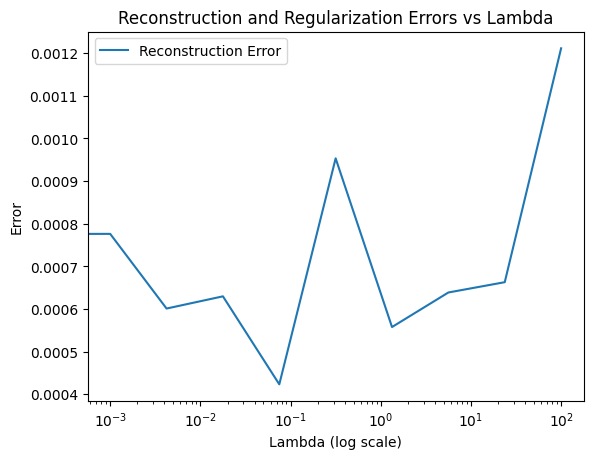

In [10]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
# plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
# plt.ylim(0, 0.06)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

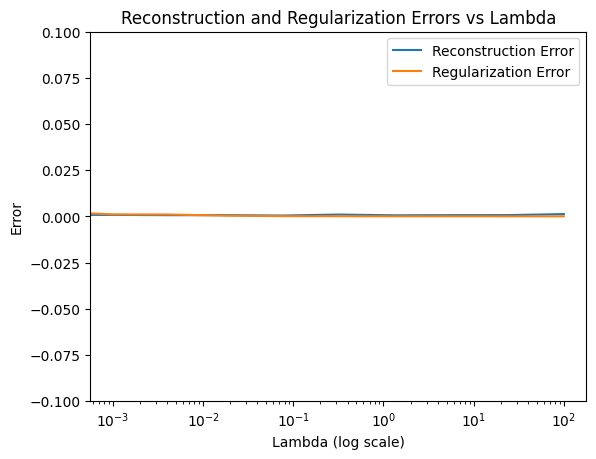

In [13]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
plt.ylim(-0.1, 0.1)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

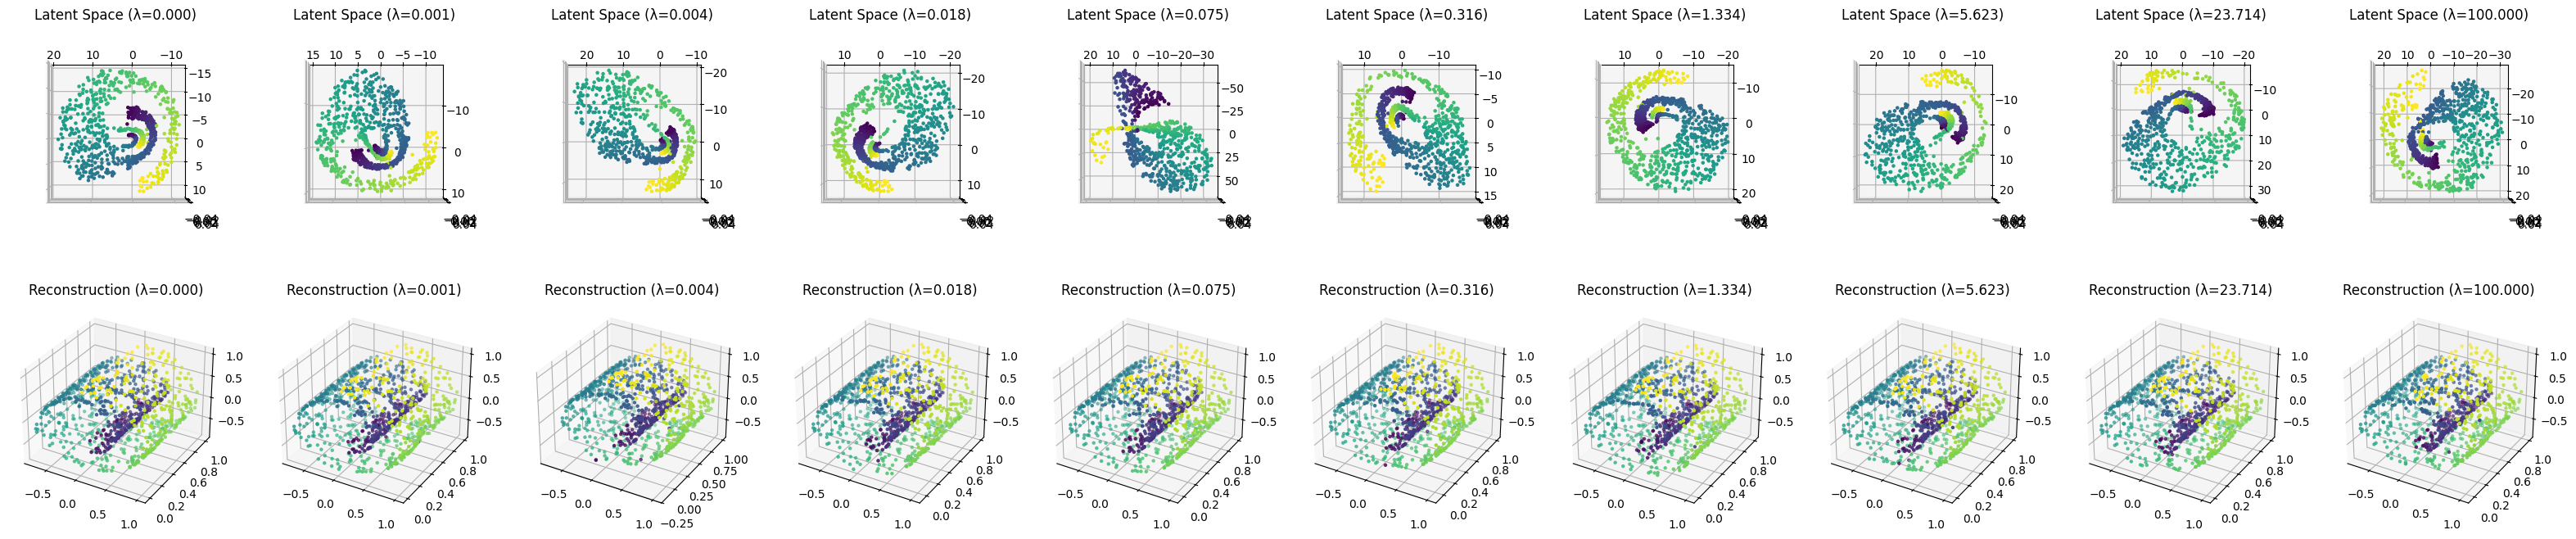

In [14]:
# plot samples and latent space at different lambdas
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 0)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=val_labels, s=5)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=val_labels, s=5)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

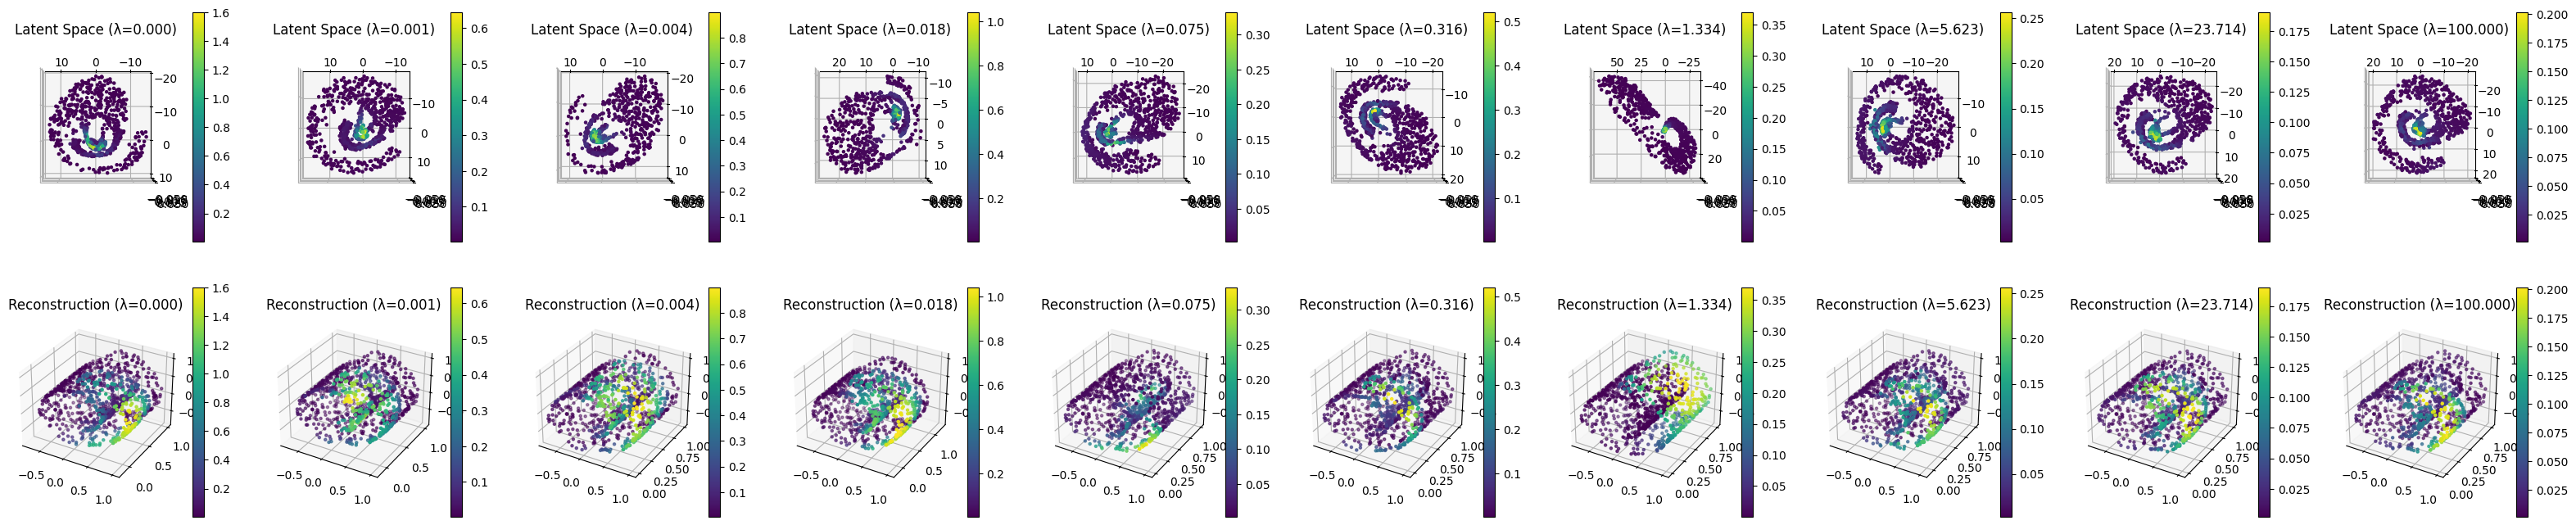

In [15]:
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 1)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    trace_vals = np.zeros_like(encoded_data[:, 0].cpu())
    for j, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decode(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decode, z)[0,:,0,:]

        # Compute the trace of J^T J
        JtJ = J.T @ J
        trace_JtJ = torch.trace(JtJ)

        # Store the trace value as a label for the point
        trace_vals[j] = trace_JtJ.item() / JtJ.shape[0]  # Normalize by the number of dimensions

    p = axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    p = axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

In [16]:
statses = []
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    statses.append(evaluate_conformality(model, data))

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

torch.cuda.DoubleTensor
tensor([0.0143, 0.0161, 0.5665,  ..., 0.0875, 0.2216, 1.0868], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([-4.7706, -4.5119, -1.4862,  ..., -4.0484, -3.0230, -0.6280],
       device='cuda:0', dtype=torch.float64)
tensor([-4.2474, -4.1284, -0.5684,  ..., -2.4364, -1.5070,  0.0832],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([0.0210, 0.0153, 0.3299,  ..., 0.1260, 0.1727, 0.6845], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([-4.2557, -4.4523, -1.8430,  ..., -3.6509, -3.3696, -0.5242],
       device='cuda:0', dtype=torch.float64)
tensor([-3.8618, -4.1803, -1.1090,  ..., -2.0717, -1.7560, -0.3791],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([0.0043, 0.9352, 0.4549,  ..., 0.0218, 0.0213, 0.6737], device='cuda:0',
       dtype=torch.flo

In [17]:
styled_df = df.style \
    .background_gradient(subset=[
            'reconstruction_error',
            'diagonal_gini',
            'lambda_std',
            'lambda_std_normed',
            'off_diag_mean',
            'off_diag_norm',
            'off_diag_mean_normed',
            'off_diag_norm_normed',
            'jTj_minus_lambdaI_mean',
            'jTj_minus_lambdaI_norm',
            'jTj_minus_lambdaI_mean_normed',
            'jTj_minus_lambdaI_norm_normed',
            'determinant_vs_estimate_std',
            'log_determinant_vs_estimate_std',
            ], cmap='Reds') \
    .background_gradient(subset=[
            'log_determinant_vs_estimate_mean',
            ], cmap='Oranges') \
    .background_gradient(subset=[
        'determinant_vs_estimate_mean'
    ], cmap='Greens')\
    .background_gradient(subset=[
        'lambda_mean',
        'latent_std',
        'latent_std_max',
        'latent_std_min',
        'latent_norm',
    ], cmap='Blues')

styled_df

,reconstruction_error,diagonal_gini,lambda_mean,lambda_std,lambda_std_normed,off_diag_mean,off_diag_norm,off_diag_mean_normed,off_diag_norm_normed,jTj_minus_lambdaI_mean,jTj_minus_lambdaI_norm,jTj_minus_lambdaI_mean_normed,jTj_minus_lambdaI_norm_normed,determinant_vs_estimate_mean,determinant_vs_estimate_std,log_determinant_vs_estimate_mean,log_determinant_vs_estimate_std,latent_std,latent_std_max,latent_std_min,latent_norm
0.000000,0.000288,0.449255,0.206028,0.304374,1.477341,0.051345,0.145225,0.253972,0.718341,0.110165,0.246449,0.478599,1.063729,0.599599,0.208496,-0.590365,0.434160,5.704445,6.115676,5.293213,454.815155
0.001000,0.000240,0.444277,0.146182,0.194569,1.331004,0.030640,0.086662,0.211346,0.597777,0.058885,0.132019,0.433485,0.958850,0.656983,0.236080,-0.508815,0.466258,5.614787,6.417687,4.811886,446.345520
0.004217,0.000051,0.303503,0.304545,0.319055,1.047644,0.034966,0.098899,0.193042,0.546005,0.067983,0.148908,0.344794,0.756456,0.751579,0.254570,-0.379061,0.502490,8.053441,8.944624,7.162259,694.139893
0.017783,0.000325,0.400168,0.095822,0.137756,1.437619,0.022454,0.063511,0.217334,0.614714,0.043260,0.096361,0.417419,0.926221,0.692883,0.217027,-0.441870,0.449197,6.803591,7.387886,6.219296,541.031677
0.074989,0.000236,0.360048,0.198489,0.212082,1.068481,0.034695,0.098134,0.229345,0.648686,0.063899,0.142162,0.409369,0.908192,0.683534,0.237421,-0.464826,0.461427,6.299962,7.153230,5.446693,510.577332
0.316228,0.000301,0.411971,0.064448,0.086682,1.344984,0.017157,0.048526,0.223949,0.633423,0.030705,0.067077,0.429935,0.961762,0.657393,0.231194,-0.503588,0.454073,7.128086,7.908146,6.348025,566.177673
1.333521,0.000206,0.377640,0.111867,0.129583,1.158366,0.014593,0.041275,0.188981,0.534519,0.029981,0.065966,0.377801,0.839233,0.715458,0.238793,-0.412954,0.438304,7.366115,8.111855,6.620374,603.993652
5.623413,0.000247,0.357650,0.072627,0.089545,1.232937,0.010102,0.028574,0.175754,0.497108,0.020345,0.045222,0.354580,0.798037,0.759766,0.208692,-0.329101,0.371061,6.989665,6.999890,6.979440,544.842529
23.713737,0.000010,0.288826,0.042458,0.055576,1.308974,0.003452,0.009764,0.247408,0.699776,0.006032,0.013229,0.391821,0.859592,0.640683,0.311455,-0.607748,0.623363,19.670845,23.088415,16.253275,1759.219849
100.000000,0.000183,0.407799,0.021429,0.027541,1.285215,0.003597,0.010174,0.202000,0.571343,0.007168,0.015828,0.405901,0.888686,0.705028,0.217700,-0.414671,0.398065,11.037397,12.029051,10.045743,871.359375


In [9]:
statses = []
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    statses.append(evaluate_conformality(model, data))

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


torch.cuda.DoubleTensor
tensor([0.6213, 0.2042, 2.0084,  ..., 0.3635, 0.5670, 0.7102], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([-1.0954, -1.6739,  0.4218,  ..., -1.3809, -0.6301, -0.3650],
       device='cuda:0', dtype=torch.float64)
tensor([-0.4759, -1.5889,  0.6973,  ..., -1.0119, -0.5673, -0.3423],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([1.7715, 1.4062, 1.2324,  ..., 1.4510, 0.7043, 1.5464], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([ 0.5416,  0.1700,  0.0863,  ...,  0.3221, -0.4204,  0.2987],
       device='cuda:0', dtype=torch.float64)
tensor([ 0.5718,  0.3409,  0.2090,  ...,  0.3723, -0.3506,  0.4359],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([0.9276, 0.7444, 0.6094,  ..., 0.9543, 0.9126, 0.3739], device='cuda:0',
       dtype=torch.flo